**<h1 align="center">Feature EDA</h1>**

This notebook analyzes the semantic and ontology-based features used in the retrieval and reranking pipeline. Using the validation split, it examines their discriminative power and complementary effects through distributional analysis, ROC–AUC, and ranking comparisons. The analysis provides insight into how ESCO-derived skill signals enhance SBERT-based retrieval and improve reranking performance.

# Table of Contents
* [1. Imports & Setup](#chapter1)
* [2. Load Results](#chapter2)
* [3. Analysis](#chapter3)
    * [3.1. SBERT discriminative power](#sub-section-3_1)
    * [3.2. ESCO features discriminative power](#sub-section-3_2)
    * [3.3. Joint view: SBERT vs best ESCO feature](#sub-section-3_3)
    * [3.4. AUC per features](#sub-section-3_4)
    * [3.5. Complementary numerically](#sub-section-3_5)
    * [3.6. Statistical tests: Mann–Whitney U + Cliff’s delta](#sub-section-3_6)
    * [3.7. Other ESCO features](#sub-section-3_7)
    * [3.8. idf_overlap_sum vs idf_overlap_sum_parent](#sub-section-3_8)

<a class="anchor" id="chapter1"></a>

# 1. Imports & Setup

</a>

In [1]:
import sys
import math
from datetime import datetime
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm

from sklearn.metrics import roc_auc_score
from scipy.stats import mannwhitneyu

In [2]:
# Project root (assumes notebook is in /Notebook)
PROJECT_ROOT = Path("..").resolve()

# Allow imports from project root
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

In [3]:
DATA_DIR = PROJECT_ROOT / "Data" / "TopK"
RESULTS_PATH = PROJECT_ROOT / "Results"

TIME = datetime.now().strftime("%m%d%Y_%H%M")

<a class="anchor" id="chapter2"></a>

# 2. Load Data

</a>

In [ ]:
# Load top-K candidate sets produced in notebook 05
val_topk_feat_off = pd.read_parquet(DATA_DIR / "val_topk_feat_off.parquet")

# Load hybrid tuning table produced in notebook 05
tuning_table = pd.read_csv(RESULTS_PATH / "Hybrid"/ "ESCO_tuning_offshelf_VAL_01222026_1755.csv")
best = tuning_table.iloc[0]  # best['esco_col'], best['alpha']

# Load reranker scored tables produced in notebook 06
val_logreg_scored = pd.read_parquet(RESULTS_PATH / "Rerankers" / "val_logreg_scored.parquet")
val_xgb_scored = pd.read_parquet(RESULTS_PATH / "Rerankers"/ "val_xgb_scored.parquet")

In [5]:
# Prevent categorical comparison errors
for df in [val_topk_feat_off, val_logreg_scored, val_xgb_scored]:
    df["candidate_occ_uri"] = df["candidate_occ_uri"].astype(str)
    df["true_occ_uri"] = df["true_occ_uri"].astype(str)

In [6]:
# Base DF for EDA
df_feat = val_topk_feat_off.copy()
df_feat["is_true"] = (df_feat["candidate_occ_uri"] == df_feat["true_occ_uri"]).astype(int)

<a class="anchor" id="chapter3"></a>

# 3. Analysis

</a>

In [7]:
QUERY_COLS = ("person_id", "t")
KEY_COLS = ["person_id", "t", "candidate_occ_uri", "true_occ_uri"]

ALL_FEATURES = [
    "sbert_score",
    "overlap_count",
    "occ_coverage",
    "cv_coverage",
    "jaccard",
    "idf_overlap_sum",
    "idf_overlap_mean",
    "occ_avg_skill_idf",
    "idf_overlap_sum_parent",
]

In [8]:
# Min-max normalize a feature within each query (person_id, t)
def minmax_norm_per_query(df, col, query_cols=QUERY_COLS, eps=1e-9):
    grp = df.groupby(list(query_cols))[col]
    mn = grp.transform("min")
    mx = grp.transform("max")
    return (df[col] - mn) / (mx - mn + eps)

In [9]:
# Rerank candidates within each query based on a given score
def rerank_with_score(df, score_col, query_cols=QUERY_COLS):
    out = df.copy()
    out["new_rank"] = out.groupby(list(query_cols))[score_col].rank(ascending=False, method="first")
    return out

In [10]:
# Compute Recall@10 from reranked candidate lists
def recall_at_10(df_ranked, rank_col="new_rank", query_cols=QUERY_COLS):
    true_ranks = (
        df_ranked[df_ranked["is_true"] == 1]
        .groupby(list(query_cols))[rank_col]
        .min()
    )
    num_q = df_ranked.groupby(list(query_cols)).ngroups
    return float((true_ranks <= 10).sum() / num_q)

In [11]:
# Estimate pairwise ROC-AUC by comparing positive vs sampled negatives within queries
def auc_for_feature(df, score_col, n_neg_per_query=49, seed=42):

    rng = np.random.default_rng(seed)
    y_true_list, y_score_list = [], []

    for _, g in df.groupby(list(QUERY_COLS), sort=False):
        is_true = g["is_true"].values.astype(bool)
        if not is_true.any():
            continue

        # Extract positive example (true next occupation)
        pos_idx = np.flatnonzero(is_true)[0]
        pos_score = g.iloc[pos_idx][score_col]
        if not np.isfinite(pos_score):
            pos_score = 0.0

        y_true_list.append(1)
        y_score_list.append(float(pos_score))

        # Sample negatives within the same query
        neg_idx = np.flatnonzero(~is_true)
        if len(neg_idx) == 0:
            continue

        take = min(n_neg_per_query, len(neg_idx))
        sampled = rng.choice(neg_idx, size=take, replace=False)

        neg_scores = (
            g.iloc[sampled][score_col]
            .replace([np.inf, -np.inf], np.nan)
            .fillna(0.0)
            .astype(float)
            .values
        )

        y_true_list.extend([0] * len(neg_scores))
        y_score_list.extend(neg_scores.tolist())

    # Return NaN if only one class is present
    if len(set(y_true_list)) < 2:
        return np.nan

    return float(roc_auc_score(np.array(y_true_list, dtype=int), np.array(y_score_list, dtype=float)))

In [12]:
# Plot score distributions for positives vs negatives (with optional negative subsampling)
def plot_pos_vs_all_distributions(df, score_col, title, bins=60, sample_neg=200000, seed=42):

    pos = df.loc[df["is_true"] == 1, score_col].replace([np.inf, -np.inf], np.nan).dropna().astype(float).values
    neg = df.loc[df["is_true"] == 0, score_col].replace([np.inf, -np.inf], np.nan).dropna().astype(float)

    # Subsample negatives to keep plots readable
    if sample_neg is not None and len(neg) > sample_neg:
        neg = neg.sample(sample_neg, random_state=seed)
    neg = neg.values

    plt.figure(figsize=(8, 4.5))
    plt.hist(neg, bins=bins, density=True, alpha=0.35, label="Negatives (sampled)" if sample_neg else "Negatives")
    plt.hist(pos, bins=bins, density=True, alpha=0.55, label="Positives (true next occ)")
    plt.title(title)
    plt.xlabel(score_col)
    plt.ylabel("Density")
    plt.legend()
    plt.tight_layout()
    plt.show()

In [13]:
# Sample a small number of negatives per query for visualization (keeps all positives)
def sample_negatives_per_query(df, n_neg=5, seed=42):

    rng = np.random.default_rng(seed)
    out_rows = []

    for _, g in df.groupby(list(QUERY_COLS), sort=False):
        pos = g[g["is_true"] == 1]
        neg = g[g["is_true"] == 0]

        if len(pos) > 0:
            out_rows.append(pos)

        if len(neg) > 0:
            take = min(n_neg, len(neg))
            idx = rng.choice(neg.index.to_numpy(), size=take, replace=False)
            out_rows.append(neg.loc[idx])

    if not out_rows:
        return df.iloc[0:0].copy()

    return pd.concat(out_rows, axis=0).reset_index(drop=True)

In [14]:
# Plot joint scatter of two features (positives vs sampled negatives)
def plot_joint_scatter(df, x_col, y_col, title, n_neg_per_query=5, seed=42):
    df_s = sample_negatives_per_query(df, n_neg=n_neg_per_query, seed=seed)

    x = df_s[x_col].replace([np.inf, -np.inf], np.nan).fillna(0.0).astype(float).values
    y = df_s[y_col].replace([np.inf, -np.inf], np.nan).fillna(0.0).astype(float).values
    c = df_s["is_true"].values

    plt.figure(figsize=(6.5, 6))
    neg_mask = (c == 0)
    pos_mask = (c == 1)
    plt.scatter(x[neg_mask], y[neg_mask], s=10, alpha=0.15, label="Negatives")
    plt.scatter(x[pos_mask], y[pos_mask], s=18, alpha=0.8, label="Positives")
    plt.title(title)
    plt.xlabel(x_col)
    plt.ylabel(y_col)
    plt.legend()
    plt.tight_layout()
    plt.show()

In [16]:
def plot_combined_feature_figure(
    df_hist,
    df_density,
    sample_neg=200000,
    seed=42,
    hist_bins=60,
    density_bins=60
):
    fig, axes = plt.subplots(2, 2, figsize=(12, 9))

    def plot_distribution(ax, df, score_col, xlabel, panel_label):
        pos = (
            df.loc[df["is_true"] == 1, score_col]
            .replace([np.inf, -np.inf], np.nan)
            .dropna()
            .astype(float)
            .values
        )

        neg = (
            df.loc[df["is_true"] == 0, score_col]
            .replace([np.inf, -np.inf], np.nan)
            .dropna()
            .astype(float)
        )

        if sample_neg is not None and len(neg) > sample_neg:
            neg = neg.sample(sample_neg, random_state=seed)

        neg = neg.values

        ax.hist(neg, bins=hist_bins, density=True, alpha=0.35, label="Negatives")
        ax.hist(pos, bins=hist_bins, density=True, alpha=0.55, label="Positives")
        ax.set_title(panel_label)
        ax.set_xlabel(xlabel)
        ax.set_ylabel("Density")
        ax.legend()

    # (a) Occupation coverage distribution
    plot_distribution(
        axes[0, 0],
        df_hist,
        score_col="occ_coverage",
        xlabel="Occupation coverage",
        panel_label="(a) Occupation coverage"
    )

    # (b) SBERT similarity distribution
    plot_distribution(
        axes[0, 1],
        df_hist,
        score_col="sbert_score",
        xlabel="SBERT similarity",
        panel_label="(b) SBERT similarity"
    )

    x_col = "sbert_score"
    y_col = "occ_coverage_norm"

    plot_df = (
        df_density[[x_col, y_col, "is_true"]]
        .replace([np.inf, -np.inf], np.nan)
        .dropna()
        .copy()
    )

    x_range = (plot_df[x_col].min(), plot_df[x_col].max())
    y_range = (plot_df[y_col].min(), plot_df[y_col].max())

    # (c) Positive density
    pos_df = plot_df[plot_df["is_true"] == 1]

    h_pos = axes[1, 0].hist2d(
        pos_df[x_col],
        pos_df[y_col],
        bins=density_bins,
        range=[x_range, y_range],
        norm=LogNorm(vmin=1)
    )

    axes[1, 0].set_title("(c) Positive CV–occupation pairs")
    axes[1, 0].set_xlabel("SBERT similarity")
    axes[1, 0].set_ylabel("Occupation coverage")
    fig.colorbar(h_pos[3], ax=axes[1, 0], label="Count")

    # (d) Negative density
    neg_df = plot_df[plot_df["is_true"] == 0]

    h_neg = axes[1, 1].hist2d(
        neg_df[x_col],
        neg_df[y_col],
        bins=density_bins,
        range=[x_range, y_range],
        norm=LogNorm(vmin=1)
    )

    axes[1, 1].set_title("(d) Negative CV–occupation pairs")
    axes[1, 1].set_xlabel("SBERT similarity")
    axes[1, 1].set_ylabel("Occupation coverage")
    fig.colorbar(h_neg[3], ax=axes[1, 1], label="Count")

    plt.tight_layout()
    plt.show()

<a class="anchor" id="sub-section-3_1"></a>

## 3.1. SBERT discriminative power

</a>

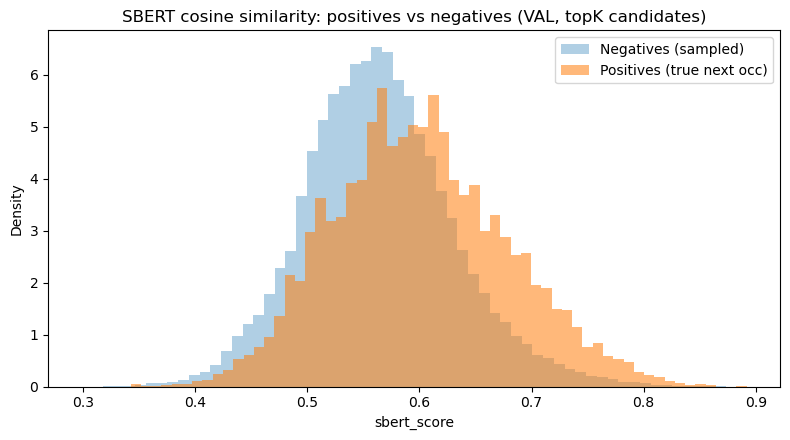

In [17]:
plot_pos_vs_all_distributions(
    df_feat,
    score_col="sbert_score",
    title="SBERT cosine similarity: positives vs negatives (VAL, topK candidates)",
    bins=60,
    sample_neg=200000
)

Distributional analysis of SBERT cosine similarity within the Top-K candidate set shows a rightward shift for true transitions relative to negative candidates, confirming that semantic similarity contains useful signals. On average, the true next occupation is more semantically related to prior experience than unrelated alternatives. However, the distributions exhibit substantial overlap, and many negative candidates receive similarity scores comparable to or exceeding those of the true transition.

<a class="anchor" id="sub-section-3_2"></a>

## 3.2. ESCO features discriminative power

</a>

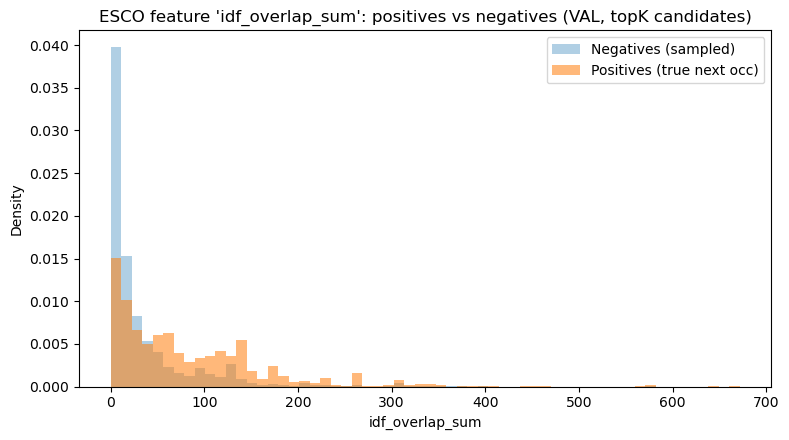

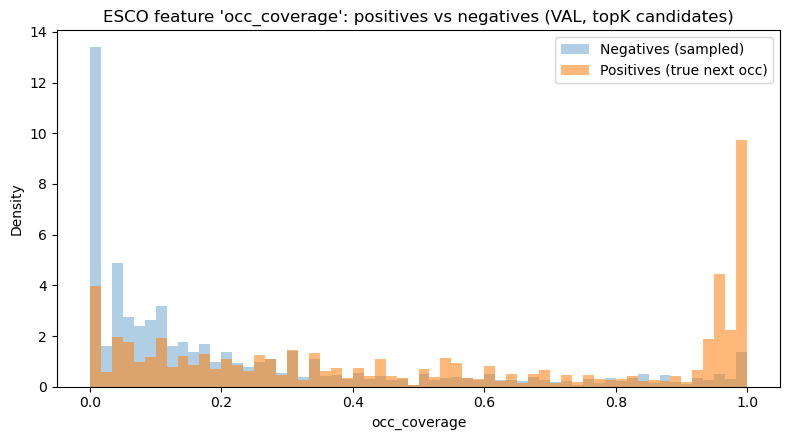

In [18]:
for col in ["idf_overlap_sum", "occ_coverage"]:
    plot_pos_vs_all_distributions(
        df_feat,
        score_col=col,
        title=f"ESCO feature '{col}': positives vs negatives (VAL, topK candidates)",
        bins=60,
        sample_neg=200000
    )

**occ_coverage:** True transitions tend to cluster at higher coverage values, whereas negative candidates concentrate near zero. 

For completeness, ESCO features are also visualized after per-query min–max normalization, as used in the hybrid scoring function. This ensures comparability with the reranking setup, although the analysis focuses on the original (unnormalized) feature distributions.

In [19]:
# Normalized per-query ESCO (matches how hybrid uses ESCO)
df_feat_norm = df_feat.copy()
df_feat_norm["idf_overlap_sum_norm"] = minmax_norm_per_query(df_feat_norm, "idf_overlap_sum")
df_feat_norm["occ_coverage_norm"] = minmax_norm_per_query(df_feat_norm, "occ_coverage")

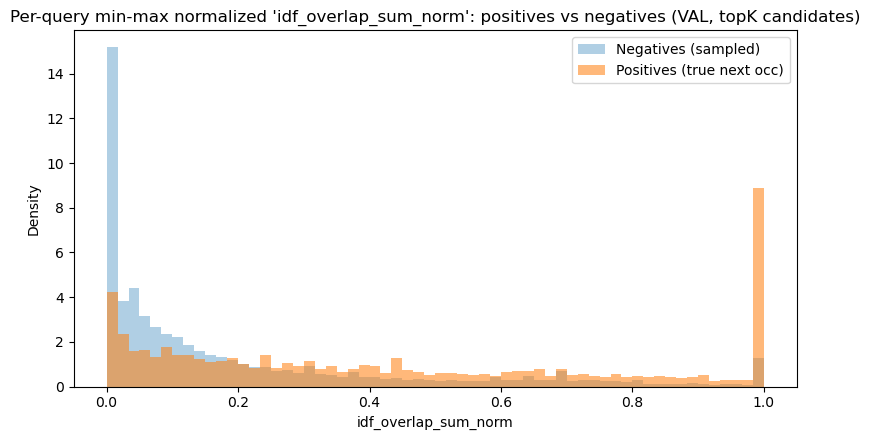

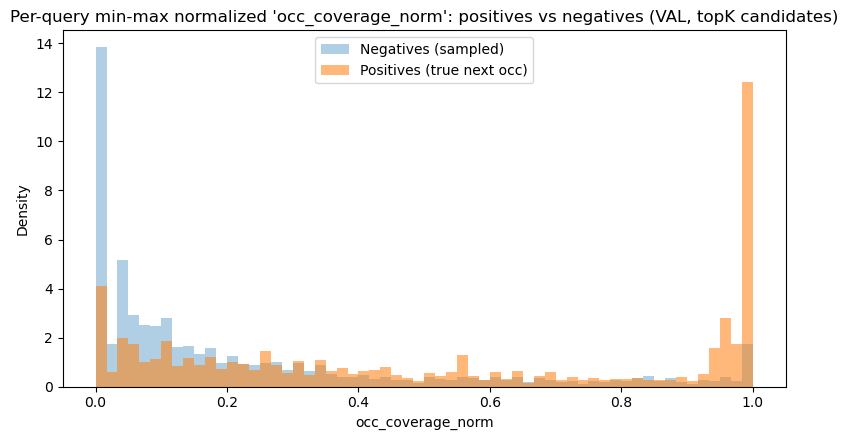

In [20]:
for col in ["idf_overlap_sum_norm", "occ_coverage_norm"]:
    plot_pos_vs_all_distributions(
        df_feat_norm,
        score_col=col,
        title=f"Per-query min-max normalized '{col}': positives vs negatives (VAL, topK candidates)",
        bins=60,
        sample_neg=200000
    )

<a class="anchor" id="sub-section-3_3"></a>

## 3.3. Joint view: SBERT vs best ESCO feature

</a>

/tmp/ipython-input-1464521709.py:17: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


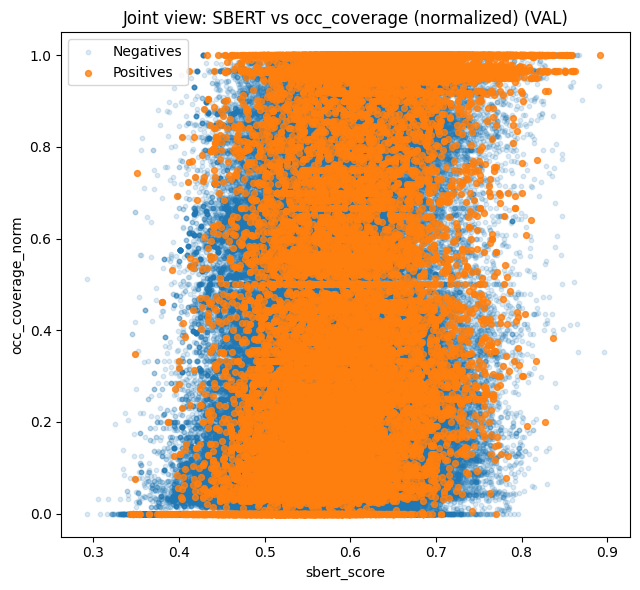

In [ ]:
# Use normalized ESCO for interpretability on the same [0,1] scale
plot_joint_scatter(
    df_feat_norm,
    x_col="sbert_score",
    y_col="occ_coverage_norm",
    title="Joint view: SBERT vs occ_coverage (normalized) (VAL)",
    n_neg_per_query=5
)

SBERT similarity values also display a compressed range, with many candidates receiving similar cosine scores and clustering within a relatively narrow SBERT score range in the joint scatter plot. 

In [ ]:
print("Spearman corr (SBERT, occ_coverage):")
display(df_feat[["sbert_score", "occ_coverage"]].corr(method="spearman"))

Spearman corr (SBERT, occ_coverage):


,sbert_score,occ_coverage
sbert_score,1.000000,0.338821
occ_coverage,0.338821,1.000000


/tmp/ipython-input-1464521709.py:17: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()


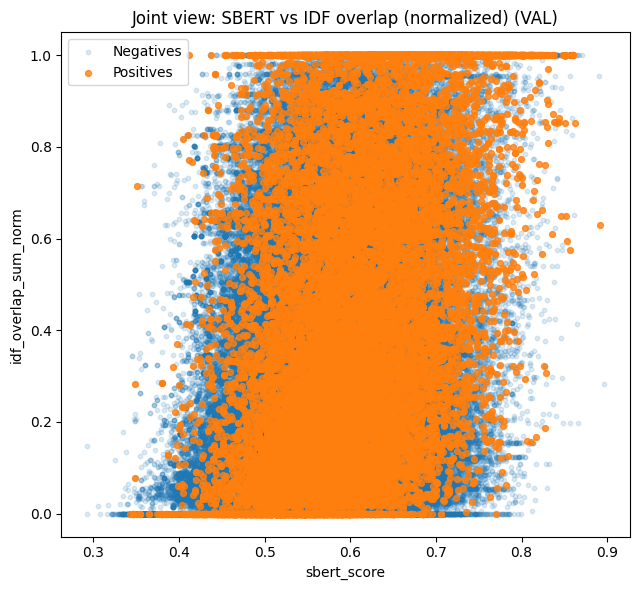

In [ ]:
plot_joint_scatter(
    df_feat_norm,
    x_col="sbert_score",
    y_col="idf_overlap_sum_norm",
    title="Joint view: SBERT vs IDF overlap (normalized) (VAL)",
    n_neg_per_query=5
)

In [ ]:
print("Spearman corr (SBERT, idf_overlap_sum):")
display(df_feat[["sbert_score", "idf_overlap_sum"]].corr(method="spearman"))

Spearman corr (SBERT, idf_overlap_sum):


,sbert_score,idf_overlap_sum
sbert_score,1.000000,0.340676
idf_overlap_sum,0.340676,1.000000


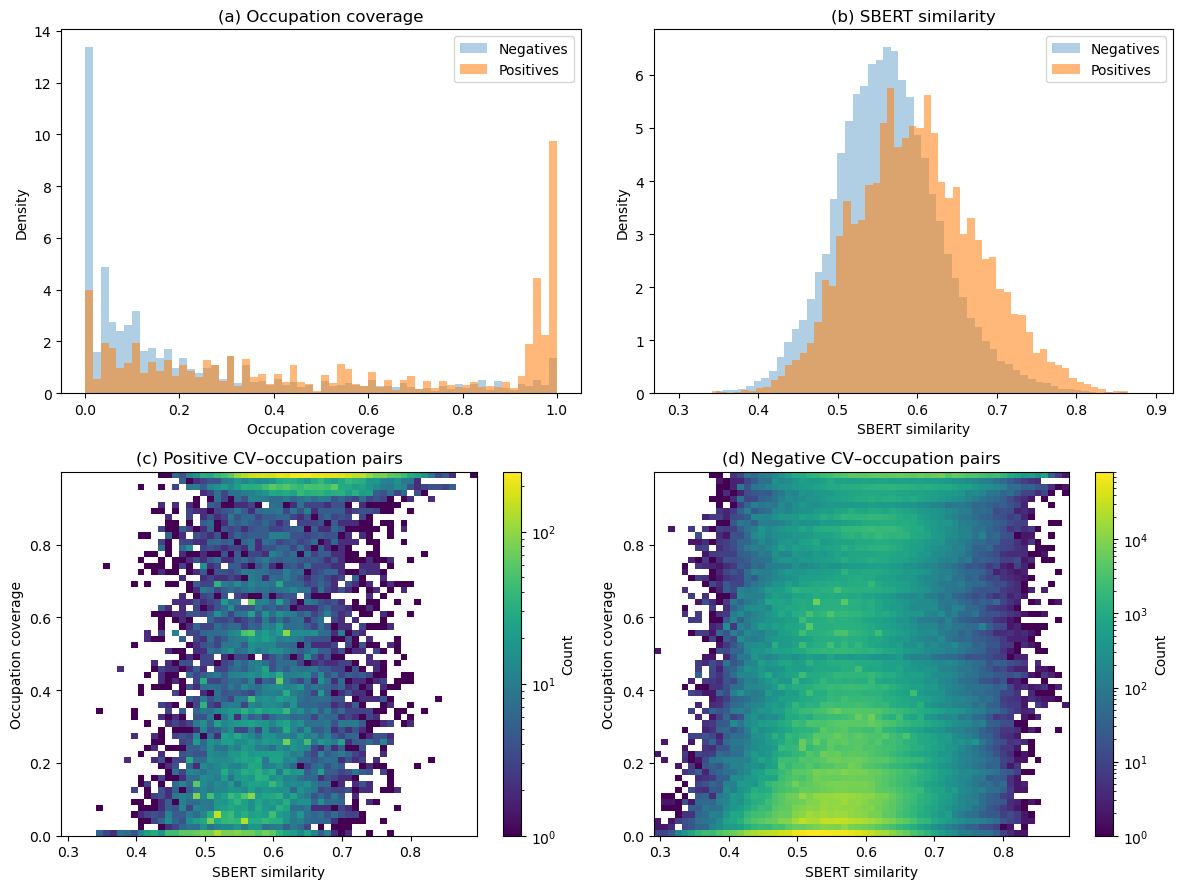

In [21]:
plot_combined_feature_figure(
    df_hist=df_feat,
    df_density=df_feat_norm,
    sample_neg=200000,
    hist_bins=60,
    density_bins=60
)

<a class="anchor" id="sub-section-3_4"></a>

## 3.4. AUC per features

</a>

In [ ]:
auc_rows = []
for col in ALL_FEATURES:
    auc_rows.append({"feature": col, "auc": auc_for_feature(df_feat, score_col=col, n_neg_per_query=49, seed=42)})

auc_df = pd.DataFrame(auc_rows).sort_values("auc", ascending=False).reset_index(drop=True)
display(auc_df)

,feature,auc
0,occ_coverage,0.720979
1,idf_overlap_mean,0.714381
2,jaccard,0.707967
3,idf_overlap_sum_parent,0.703239
4,idf_overlap_sum,0.703239
5,cv_coverage,0.698838
6,overlap_count,0.686790
7,sbert_score,0.640062
8,occ_avg_skill_idf,0.623172


In pairwise AUC analysis conducted within the SBERT Top-K candidate set, occupation coverage achieves the highest individual AUC (≈ 0.7210), outperforming all other ESCO-derived features, including SBERT cosine similarity (≈ 0.6401). This indicates discriminative capacity within a semantically restricted candidate set: a random positive CV-occupation pair is ranked above a random negative pair in approximately 72% of cases. 

<a class="anchor" id="sub-section-3_5"></a>

## 3.5. Complementary numerically

</a>

In [ ]:
esco_col = str(best["esco_col"])
alpha = float(best["alpha"])

In [ ]:
# Hybrid score computed inline (per-query normalized ESCO)
df_hybrid = df_feat.copy()
esco_norm = minmax_norm_per_query(df_hybrid, esco_col)
df_hybrid["hybrid_score"] = alpha * df_hybrid["sbert_score"].astype(float) + (1 - alpha) * esco_norm.astype(float)

In [ ]:
# Merge reranker scores onto same rows as df_feat
df_logreg = df_feat.merge(
    val_logreg_scored[KEY_COLS + ["rerank_score"]],
    on=KEY_COLS,
    how="left",
    validate="one_to_one",
)
df_xgb = df_feat.merge(
    val_xgb_scored[KEY_COLS + ["rerank_score"]],
    on=KEY_COLS,
    how="left",
    validate="one_to_one",
)

In [ ]:
df_logreg["rerank_score"] = df_logreg["rerank_score"].fillna(0.0)
df_xgb["rerank_score"] = df_xgb["rerank_score"].fillna(0.0)

In [ ]:
# Recall@10
rec_sbert = recall_at_10(rerank_with_score(df_feat, "sbert_score"))
rec_esco = recall_at_10(rerank_with_score(df_feat, "occ_coverage"))
rec_hybrid = recall_at_10(rerank_with_score(df_hybrid, "hybrid_score"))
rec_logreg = recall_at_10(rerank_with_score(df_logreg, "rerank_score"))
rec_xgb = recall_at_10(rerank_with_score(df_xgb, "rerank_score"))

In [ ]:
comp_df = pd.DataFrame([
    {"system": "SBERT only (rerank topK by cosine)", "pairwise_auc": auc_for_feature(df_feat, "sbert_score"), "recall@10": rec_sbert},
    {"system": "ESCO only (occ_coverage; rerank topK)", "pairwise_auc": auc_for_feature(df_feat, "occ_coverage"), "recall@10": rec_esco},
    {"system": f"Hybrid (alpha={alpha:.2f}, esco={esco_col})", "pairwise_auc": auc_for_feature(df_hybrid, "hybrid_score"), "recall@10": rec_hybrid},
    {"system": "LogReg reranker (SBERT + ESCO)", "pairwise_auc": auc_for_feature(df_logreg, "rerank_score"), "recall@10": rec_logreg},
    {"system": "XGBoost reranker (SBERT + ESCO)", "pairwise_auc": auc_for_feature(df_xgb, "rerank_score"), "recall@10": rec_xgb},
]).sort_values("recall@10", ascending=False).reset_index(drop=True)

display(comp_df)

,system,pairwise_auc,recall@10
0,XGBoost reranker (SBERT + ESCO),0.856162,0.175355
1,LogReg reranker (SBERT + ESCO),0.764226,0.143057
2,"Hybrid (alpha=0.70, esco=occ_coverage)",0.719281,0.139984
3,ESCO only (occ_coverage; rerank topK),0.720979,0.135158
4,SBERT only (rerank topK by cosine),0.640062,0.109776


System-level results reveal that semantic and ontology-derived signals are complementary, and that combining them improves ranking performance. The table shows pairwise discrimination (AUC) and retrieval effectiveness (Recall@10) across ranking strategies within the SBERT Top-K candidate set. Relative to the SBERT semantic baseline, the XGBoost reranker improves Recall@10 from 0.1098 to 0.1754 on the test set, corresponding to approximately a 58% relative improvement. SBERT similarity exhibits the weakest performance in both AUC and Recall@10, whereas occupation coverage improves both metrics. Although the hybrid configuration slightly reduces global pairwise separability (AUC) compared to coverage alone, it improves top-ranked ordering quality. Learned rerankers yield the strongest results: logistic regression improves both AUC and Recall@10 relative to the fixed hybrid, while XGBoost achieves the highest performance overall, increasing AUC to 0.8562 and Recall@10 to 0.1754.

<a class="anchor" id="sub-section-3_6"></a>

## 3.6. Statistical tests: Mann–Whitney U + Cliff’s delta

</a>

In [ ]:
# Extract positive scores and sampled negative scores per query (limits number of negatives to control memory usage)
def get_pos_neg_scores(df, score_col, n_neg_per_query=10, seed=42, max_neg_total=500_000):
    """
    Extract positives + sampled negatives per query, with an optional global cap on negatives.
    """
    rng = np.random.default_rng(seed)
    pos_scores, neg_scores = [], []

    for _, g in df.groupby(list(QUERY_COLS), sort=False):
        # Get positive example (true next occupation)
        pos = g[g["is_true"] == 1]
        if len(pos) == 0:
            continue
        pos_scores.append(float(pos.iloc[0][score_col]))

        # Sample negatives within the same query
        neg = g[g["is_true"] == 0]
        if len(neg) > 0:
            take = min(n_neg_per_query, len(neg))
            idx = rng.choice(neg.index.to_numpy(), size=take, replace=False)
            neg_scores.extend(df.loc[idx, score_col].astype(float).tolist())

        # Stop early if global negative cap is reached
        if max_neg_total is not None and len(neg_scores) >= max_neg_total:
            break

    return np.asarray(pos_scores, dtype=np.float32), np.asarray(neg_scores, dtype=np.float32)

In [ ]:
# Compute Cliff's delta effect size from Mann–Whitney U statistic
def cliffs_delta_from_u(u, n_pos, n_neg):
    # Convert U statistic to Vargha-Delaney A, then to Cliff's delta
    A = u / (n_pos * n_neg)
    return float(2 * A - 1)

In [ ]:
# Run statistical test comparing positives vs negatives for a given feature
def run_stats(df, score_col, label, n_neg_per_query=10, seed=42, max_neg_total=500_000):
    # Extract sampled positive and negative scores
    pos, neg = get_pos_neg_scores(df, score_col, n_neg_per_query=n_neg_per_query, seed=seed, max_neg_total=max_neg_total)
    
    # Mann–Whitney U test: do positives tend to have higher scores than negatives?
    u, p = mannwhitneyu(pos, neg, alternative="greater")
    # Compute effect size (Cliff's delta)
    delta = cliffs_delta_from_u(u, len(pos), len(neg))
    return {
        "feature": label,
        "score_col": score_col,
        "n_pos": int(len(pos)),
        "n_neg": int(len(neg)),
        "mw_u": float(u),
        "mw_pvalue": float(p),
        "effect_delta": float(delta),
    }

In [ ]:
# Run statistical comparisons across different scoring methods
results = [
    run_stats(df_feat, "sbert_score",  "SBERT similarity", n_neg_per_query=10),
    run_stats(df_feat, "occ_coverage", "ESCO: occupation coverage", n_neg_per_query=10),
    run_stats(df_hybrid, "hybrid_score", f"Hybrid score (alpha={alpha:.2f}, esco={esco_col})", n_neg_per_query=10),
    run_stats(df_logreg, "rerank_score", "LogReg reranker", n_neg_per_query=10),
    run_stats(df_xgb, "rerank_score", "XGBoost reranker", n_neg_per_query=10),
]

stat_df = pd.DataFrame(results)

In [ ]:
# Categorize effect size based on Cliff's delta thresholds
stat_df["effect_size"] = np.where(
    stat_df["effect_delta"].abs() < 0.147, "negligible",
    np.where(
        stat_df["effect_delta"].abs() < 0.33, "small",
        np.where(
            stat_df["effect_delta"].abs() < 0.474, "medium",
            "large"
        )
    )
)

In [ ]:
# Format p-values for readability (scientific notation)
stat_df["mw_pvalue"] = stat_df["mw_pvalue"].map(lambda x: f"{x:.2e}")
display(stat_df[["feature", "effect_delta", "effect_size", "mw_pvalue", "n_pos", "n_neg"]])

,feature,effect_delta,effect_size,mw_pvalue,n_pos,n_neg
0,SBERT similarity,0.280446,small,0.00e+00,20685,206850
1,ESCO: occupation coverage,0.441093,medium,0.00e+00,20685,206850
2,"Hybrid score (alpha=0.70, esco=occ_coverage)",0.437952,medium,0.00e+00,20685,206850
3,LogReg reranker,0.528097,large,0.00e+00,20685,206850
4,XGBoost reranker,0.711960,large,0.00e+00,20685,206850


Cliff’s δ increases from SBERT similarity (0.2804, small) to occupation coverage (0.4411, medium) and the hybrid configuration (0.4380, medium), and further to logistic regression (0.5281, large) and XGBoost (0.7120, large). This pattern parallels improvements in AUC and Recall@10, suggesting that stronger stochastic dominance between score distributions translates into improved Top-K retrieval performance. 

<a class="anchor" id="sub-section-3_7"></a>

## 3.7. Other ESCO features

</a>

In [29]:
ESCO_OTHER_FEATURES = [
    "idf_overlap_mean",
    "cv_coverage",
    "jaccard",
    "overlap_count",
    "occ_avg_skill_idf",
    "idf_overlap_sum_parent",
    "idf_overlap_sum"
]

In [30]:
N_NEG_SAMPLE = 150_000   # global negative subsample for plotting
BINS = 40
RANDOM_STATE = 42

In [31]:
df_plot = df_feat.copy()

# Subsample negatives globally (for plotting only)
neg_df = df_plot[df_plot["is_true"] == 0]
if len(neg_df) > N_NEG_SAMPLE:
    neg_df = neg_df.sample(N_NEG_SAMPLE, random_state=RANDOM_STATE)

pos_df = df_plot[df_plot["is_true"] == 1]

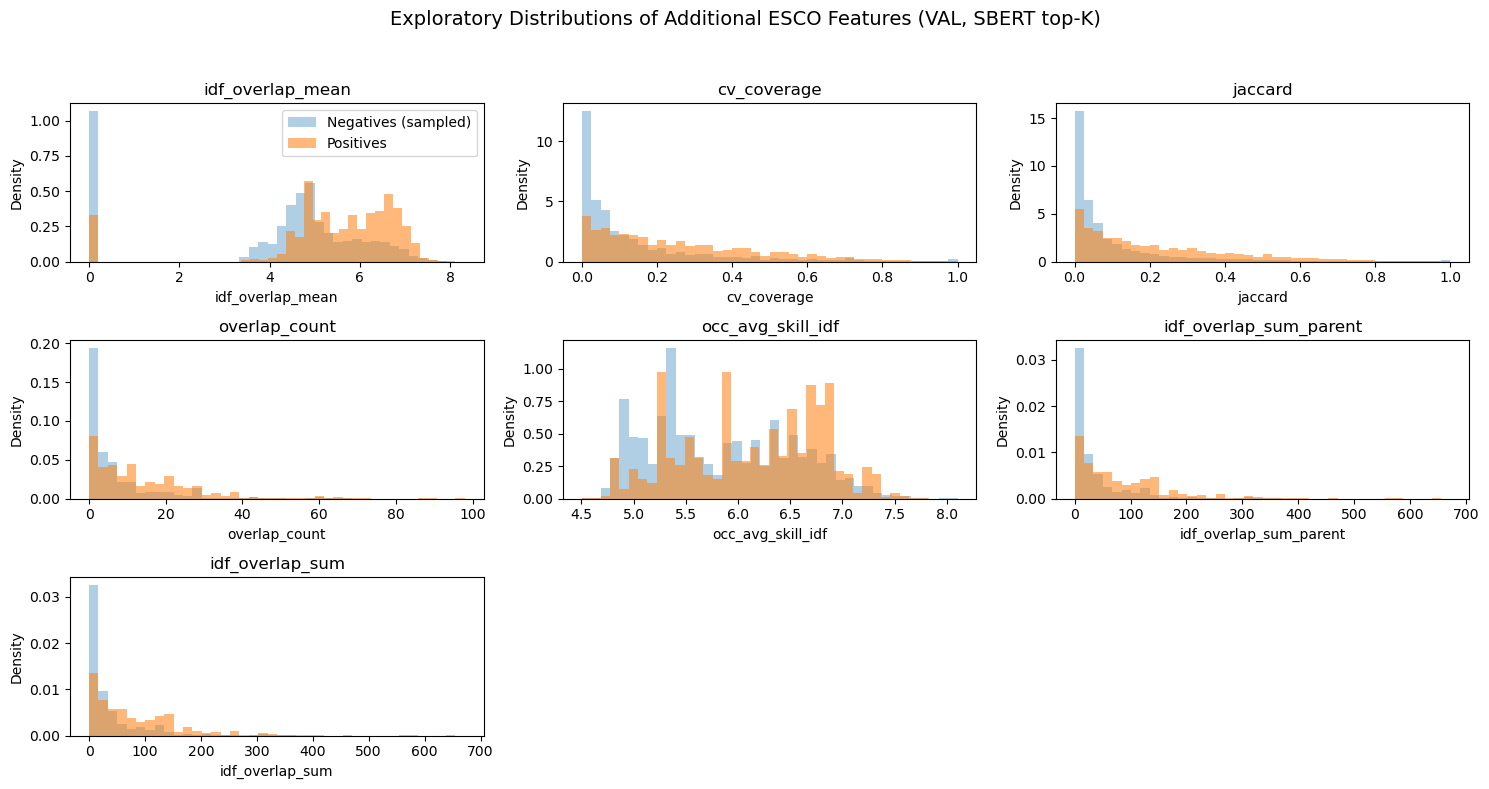

In [33]:
fig, axes = plt.subplots(3, 3, figsize=(15, 8))
axes = axes.flatten()

for ax, feat in zip(axes, ESCO_OTHER_FEATURES):
    neg_vals = neg_df[feat].replace([np.inf, -np.inf], np.nan).dropna().astype(float).values
    pos_vals = pos_df[feat].replace([np.inf, -np.inf], np.nan).dropna().astype(float).values

    ax.hist(neg_vals, bins=BINS, density=True, alpha=0.35, label="Negatives (sampled)")
    ax.hist(pos_vals, bins=BINS, density=True, alpha=0.55, label="Positives")
    ax.set_title(feat)
    ax.set_ylabel("Density")
    ax.set_xlabel(feat)

for ax in axes[len(ESCO_OTHER_FEATURES):]:
    fig.delaxes(ax)

axes[0].legend(loc="upper right")

fig.suptitle(
    "Exploratory Distributions of Additional ESCO Features (VAL, SBERT top-K)",
    fontsize=14
)

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()


<a class="anchor" id="sub-section-3_8"></a>

## 3.8. idf_overlap_sum vs idf_overlap_sum_parent

</a>

In [ ]:
diff_rate = (df_feat["idf_overlap_sum_parent"] > df_feat["idf_overlap_sum"]).mean()
same_rate = (df_feat["idf_overlap_sum_parent"] == df_feat["idf_overlap_sum"]).mean()

print("Fraction where parent overlap increases:", float(diff_rate))
print("Fraction where parent overlap unchanged:", float(same_rate))

Fraction where parent overlap increases: 0.0
Fraction where parent overlap unchanged: 1.0


In [ ]:
delta = df_feat["idf_overlap_sum_parent"] - df_feat["idf_overlap_sum"]
print(delta.describe())
print("Non-zero deltas:", int((delta > 0).sum()), "out of", int(len(delta)))

count    4424450.0
mean           0.0
std            0.0
min            0.0
25%            0.0
50%            0.0
75%            0.0
max            0.0
dtype: float64
Non-zero deltas: 0 out of 4424450


Empirical analysis revealed that the hierarchy-expanded feature was perfectly correlated with the base IDF-weighted overlap under the current experimental setup. Parent expansion therefore introduced no additional intersections beyond those already captured by exact skill matching and had no measurable effect on retrieval performance. This outcome reflects the structure of the ESCO essential skill annotations used. Occupation-skill relations are restricted to essential skills, which are typically specific and do not systematically include parent-level skills. As a result, expanding CV skills to include parent nodes rarely generated new matches when intersected with occupation skill sets. Evidence of redundancy also appears in both feature-level and model-level analyses. The hierarchy-expanded and base IDF overlap features yield identical AUC values and receive identical coefficients in logistic regression. More generally, the logistic regression model assigns negative coefficients to raw overlap measures (overlap count and Jaccard similarity), suggesting that several overlap-based measures capture closely related aspects of skill compatibility.